In [19]:
!pip install transformers python-dotenv networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from transformers import pipeline

In [20]:
# Load simple LLM
llm = pipeline("text-generation", model="gpt2")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1208.35it/s]


In [21]:
graph = nx.DiGraph()

graph.add_node("start")
graph.add_node("llm")
graph.add_node("output")

graph.add_edge("start", "llm")
graph.add_edge("llm", "output")

print("Graph ready ✅")

Graph ready ✅


In [22]:
def llm_node(question):
    try:
        response = llm(question, max_length=50, num_return_sequences=1)
        return response[0]['generated_text']
    except Exception as e:
        return f"Error: {str(e)}"


def run_workflow(question):
    print("start → llm → output\n")

    if "start" in graph:
        answer = llm_node(question)

    return answer


# Test
user_input = "What is Artificial Intelligence?"

result = run_workflow(user_input)

print("Output:\n", result)

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


start → llm → output

Output:
 What is Artificial Intelligence?

AI is a new field of research that is rapidly gaining popularity because of its ability to mimic human behavior. AI is particularly powerful because it captures information about the human brain and it can learn from it. However, it has not gotten any better. AI scientists have learned that many of the problems encountered by humans are due to their ability to communicate with each other. This knowledge is used by human beings to solve problems, but it also enables us to do things which we would never have done otherwise.

The question is how can we use AI to solve problems?

At the present time, we know that humans know that complex information is inherently unreliable. However, we can learn to trust that information, and we can use this knowledge to solve complex problems.

We can use AI to solve problems that are more complex than we previously thought.

Our ability to use AI may be used to improve our health, because 

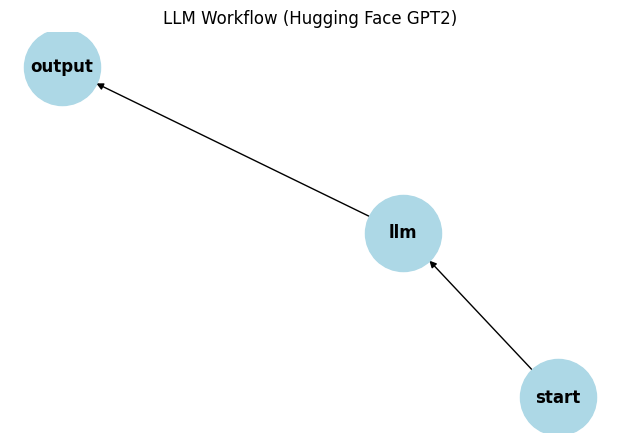

In [23]:
plt.figure(figsize=(6,4))

pos = nx.spring_layout(graph)

nx.draw(
    graph, pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=12,
    font_weight="bold",
    arrows=True
)

plt.title("LLM Workflow (Hugging Face GPT2)")
plt.show()